In [4]:
import math
import pickle

import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import ndimage
import scipy
import seaborn as sns
import torch
from tqdm import tqdm
from scipy.stats import wilcoxon, ttest_ind, ttest_1samp
from statsmodels.stats.multitest import multipletests

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

from featurevis.ops import center_and_crop_image, standardize_image
from staticnet_analyses import base, gabors
from staticnet_pilots.analyses import *
from staticnet_invariance import (
    dei_stimulus_reconfigured as dei_stimulus,
    deis_reconfigured as deis_schema,
    toy,
    toy_deis,
)
from staticnet_invariance.segmentation import find_cross

stimulus = dj.create_virtual_module('stimulus', 'pipeline_stimulus')
imagenet = dj.create_virtual_module('pipeline_imagenet', 'pipeline_imagenet')
experiment = dj.create_virtual_module('pipeline_experiment', 'pipeline_experiment')
meso = dj.create_virtual_module('pipeline_meso', 'pipeline_meso')
fuse = dj.create_virtual_module('fuse', 'pipeline_fuse')
collection = dj.create_virtual_module('collection', 'pipeline_collection')

# get manually curated neuron information 
with open('/dj-stor01/users/zhiwei/closed_loop_bad_matching_neurons_by_visual_inspection_on_summary_images.pickle', 'rb') as handle:
    manual_exclude_dic = pickle.load(handle)
    
def get_exclude_neurons(manual_exclude_dic, corr_thresh=0.42, dist_thresh=10, exclude_type='confusion', mei_key=None):
    if exclude_type == 'confusion':
        manual_exclude = manual_exclude_dic['{}-{}-{}'.format(*mei_key.values())]
        neuron_dics = (DEIClosedLoopSummaryResults.Neuron() & mei_key).fetch('neuron_id', 'matched_corr', 'matched_distance', as_dict=True, order_by='neuron_id')
        exclude_cols = [i for i, dic in enumerate(neuron_dics) if (dic['neuron_id'] in manual_exclude) or (dic['matched_corr'] < corr_thresh) or (dic['matched_distance'] > dist_thresh)]
        return exclude_cols
    else:
        manual_exclude = []
        for key, val in zip(manual_exclude_dic.keys(), manual_exclude_dic.values()):
            manual_exclude.extend([dict(animal_id=key.split('-')[0], session=key.split('-')[1], scan_idx=key.split('-')[2], neuron_id=n) for n in val])

        rel1 = DEIClosedLoopSummaryResults.Neuron & 'group_id in (241)'
        rel2 = DEIClosedLoopSummaryResults.Neuron & manual_exclude
        rel3 = DEIClosedLoopSummaryResults.Neuron & 'group_id not in (241) and matched_corr < {} or matched_distance > {}'.format(corr_thresh, dist_thresh)
        rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 7 and scan_idx = 12'
        # rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 6 and scan_idx = 8' # accidentally showed exact same stimuli for 27470-6-8 and 27470-7-12

        return rel1.proj() + rel2.proj() + rel3.proj() + rel4.proj()

def cal_dof(x,y):
    a = x.std()**2/len(x)
    b = y.std()**2/len(y)
    return (a+b)**2 / (a**2/(len(x)-1) + b**2/(len(y)-1))

# x,y has format n_pts*n_repeats(or observations)
def get_stat(x, y, alternative='two-sided'):
    print(wilcoxon(x.mean(axis=1),y.mean(axis=1), alternative=alternative))
    print('DOF: {:.2f}'.format(np.nanmean([cal_dof(i,j) for i,j in zip(x,y)])))

    stats = np.array([ttest_ind(i,j,equal_var=False, alternative=alternative) for i,j in zip(x,y)])
    temp = stats[:,0][stats[:,1]<0.05]
    print('Prior correction: Different {} {:.2f}% Less {} {:.2f}%, Greater {} {:.2f}%'.format(len(temp), len(temp)/len(x)*100, (temp<0).sum(), (temp<0).sum()/len(x)*100, (temp>0).sum(), (temp>0).sum()/len(x)*100))

    cr_temp = stats[:,0][multipletests(stats[:,1],0.05,method="fdr_bh")[0]]
    print('Post correction: Different {} {:.2f}% Less {} {:.2f}%, Greater {} {:.2f}%'.format(len(cr_temp), len(cr_temp)/len(x)*100, (cr_temp<0).sum(), (cr_temp<0).sum()/len(x)*100, (cr_temp>0).sum(), (cr_temp>0).sum()/len(x)*100))

## 3b-c

In [7]:
n_repeats = 20
n_subtypes = 3
dei_type = "DEI"
rest = 'group_id in (233, 237, 239, 243, 272) and stim_type in ("dei_control_multi") and params_id !=4 and subtype in ("dei", "control_syn", "control_nat")'
labels = ['natural control', 'synthesized control']

exclude = get_exclude_neurons(manual_exclude_dic, exclude_type='scatter')
neuron_rel = (DEIClosedLoopSummaryResults.Neuron) - exclude
n_neurons = len(neuron_rel & (DEIClosedLoopSummaryResults.Subtype & rest))
real, model, subtypes, dists, corrs = (DEIClosedLoopSummaryResults.Subtype * neuron_rel & rest).fetch('real_response', 'model_response', 'subtype', 'matched_distance', 'matched_corr', order_by='group_id, neuron_id, subtype')
real = np.stack(real).reshape(n_neurons, n_subtypes, 20)
model = model.reshape(n_neurons, n_subtypes)
subtypes = np.stack(subtypes).reshape(n_neurons, n_subtypes)
dists = dists[::n_subtypes]
corrs = corrs[::n_subtypes]
all_diags = real.mean(-1).T
all_std_diags = real.std(-1, ddof=1).T
dei_mean = all_diags[-1]
dei_std = all_std_diags[-1]

WilcoxonResult(statistic=3258.0, pvalue=2.347864350220511e-41)
DOF: 30.39
Prior correction: Different 117 36.79% Less 117 36.79%, Greater 0 0.00%
Post correction: Different 66 20.75% Less 66 20.75%, Greater 0 0.00%


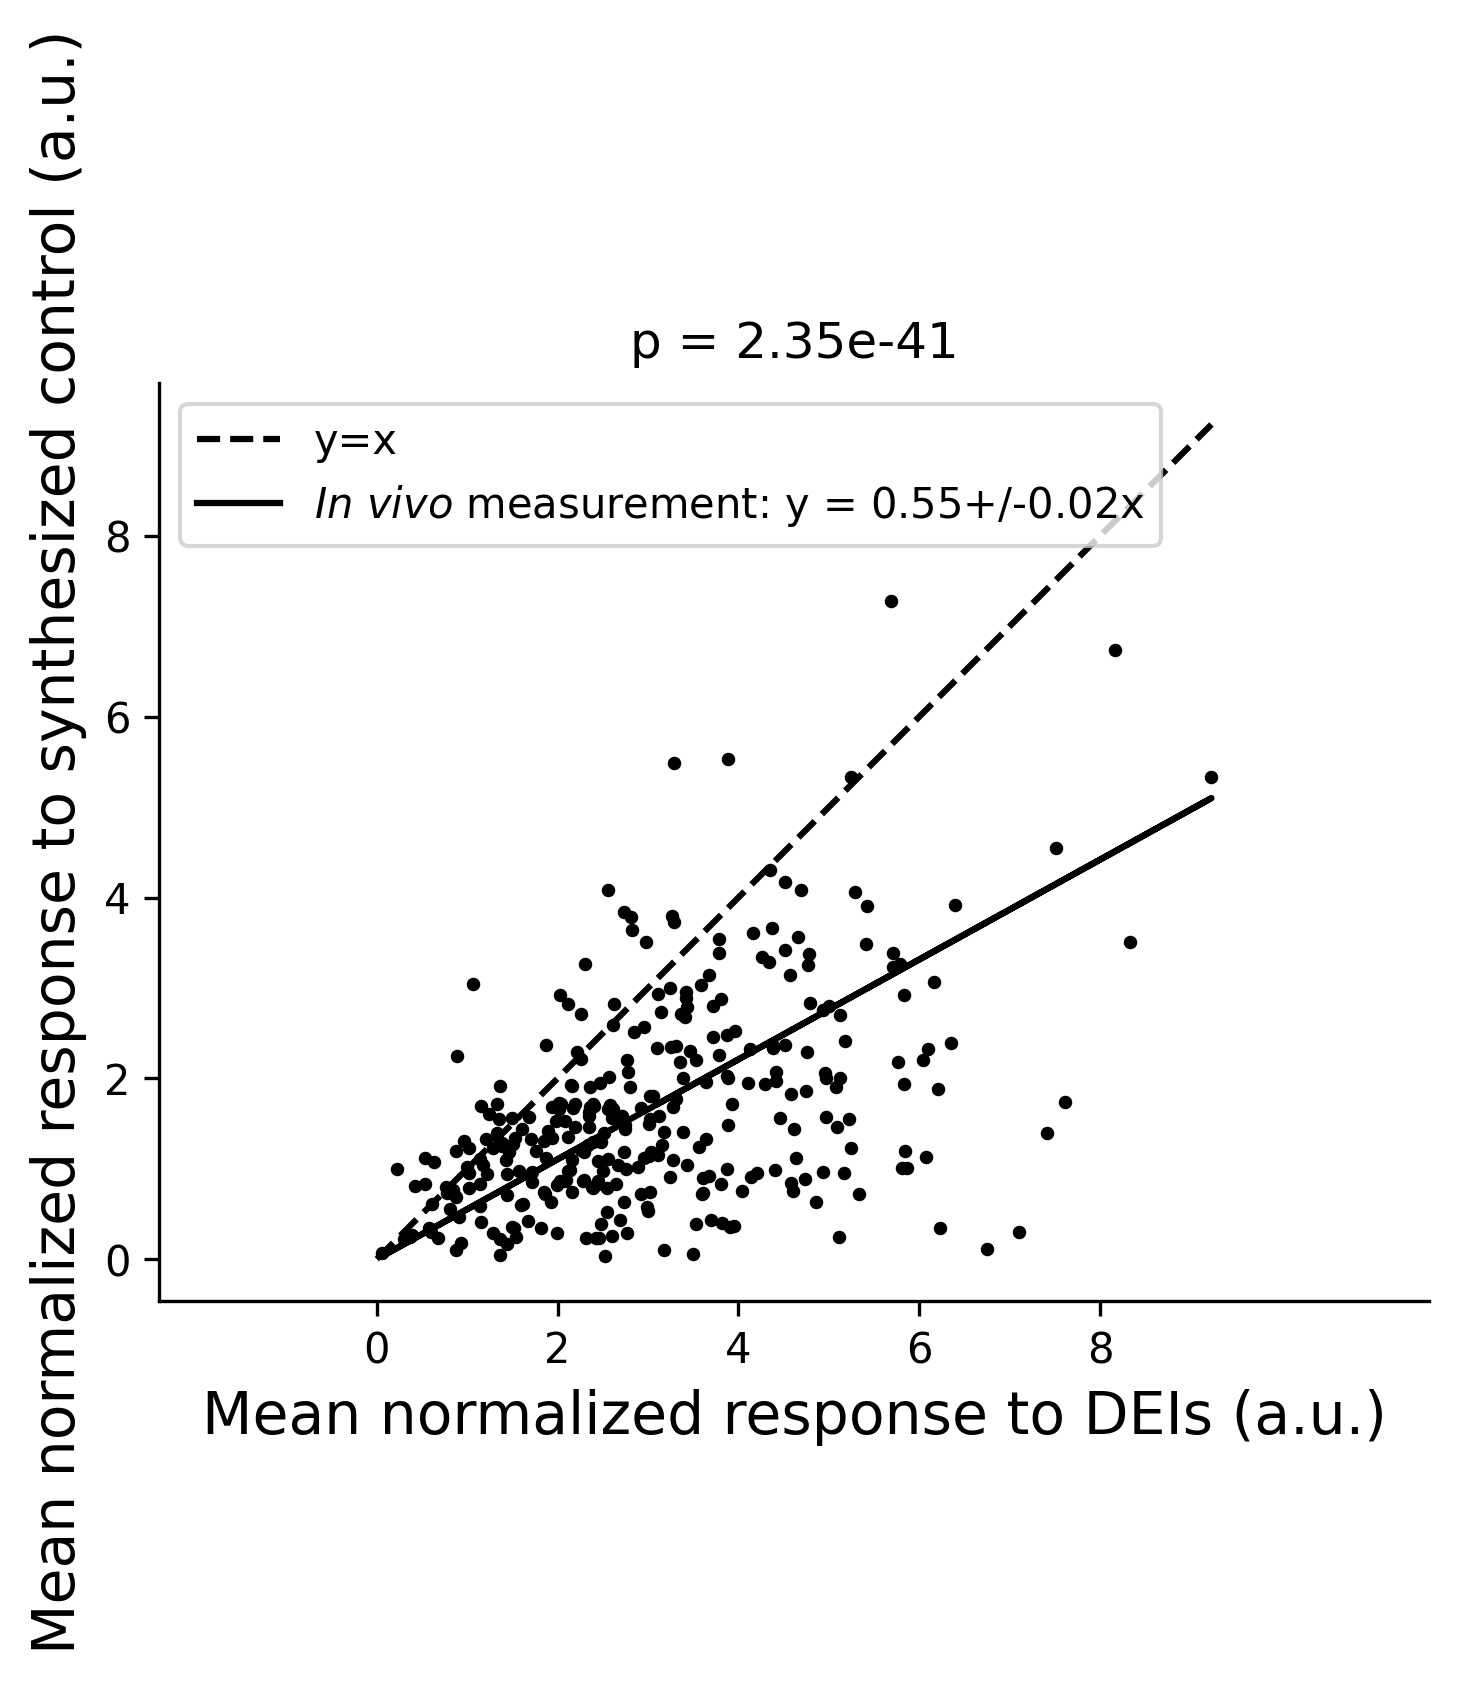

In [16]:
idx = 1
l = labels[idx]
x_mean = all_diags[idx]
x_std = all_std_diags[idx]

plt.figure(figsize=(5, 5), dpi=300)
ps = np.array([scipy.stats.ttest_ind_from_stats(m1,s1,n_repeats,m2,s2,n_repeats, equal_var=False)[1] for m1,s1,m2,s2 in zip(dei_mean, dei_std, x_mean, x_std)])
p_wc = scipy.stats.wilcoxon(dei_mean, x_mean)[1]
plt.scatter(dei_mean, x_mean, color='k', s=5, marker='o')

max_val = all_diags.max()
plt.plot([0, max_val], [0, max_val], color='k', linestyle='dashed', label='y=x')

from sklearn import linear_model
x = dei_mean[:, np.newaxis]
# robust fit
coefs = []
for i in range(1000):
    ransac = linear_model.RANSACRegressor(base_estimator=linear_model.LinearRegression(fit_intercept=False), max_trials=1000)
    ransac.fit(x, x_mean)
    coefs.append(ransac.estimator_.coef_.item())
coef = np.mean(coefs)
std_coef = np.std(coefs)
plt.plot(dei_mean, coef*dei_mean, color='k', label='$In\ vivo$ measurement: y = {:.2f}+/-{:.2f}x'.format(coef, std_coef))

plt.xlabel('Mean normalized response to DEIs (a.u.)', fontsize=14)
plt.ylabel('Mean normalized response to {} (a.u.)'.format(l), fontsize=14)

plt.title('p = {}'.format(np.format_float_scientific(p_wc, precision=2)))
plt.xticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.yticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])

plt.legend(loc=2)
sns.despine()
plt.tight_layout()
plt.axis('equal')
plt.savefig('/src/notebooks/Official_figures/[Fig3_b]Scatter_of_synthesized_control_and_DEI_responses.pdf', transparent=True)

get_stat(real[:, idx], real[:, -1])

WilcoxonResult(statistic=6442.0, pvalue=9.35930016062555e-31)
DOF: 31.07
Prior correction: Different 107 33.65% Less 100 31.45%, Greater 7 2.20%
Post correction: Different 52 16.35% Less 51 16.04%, Greater 1 0.31%


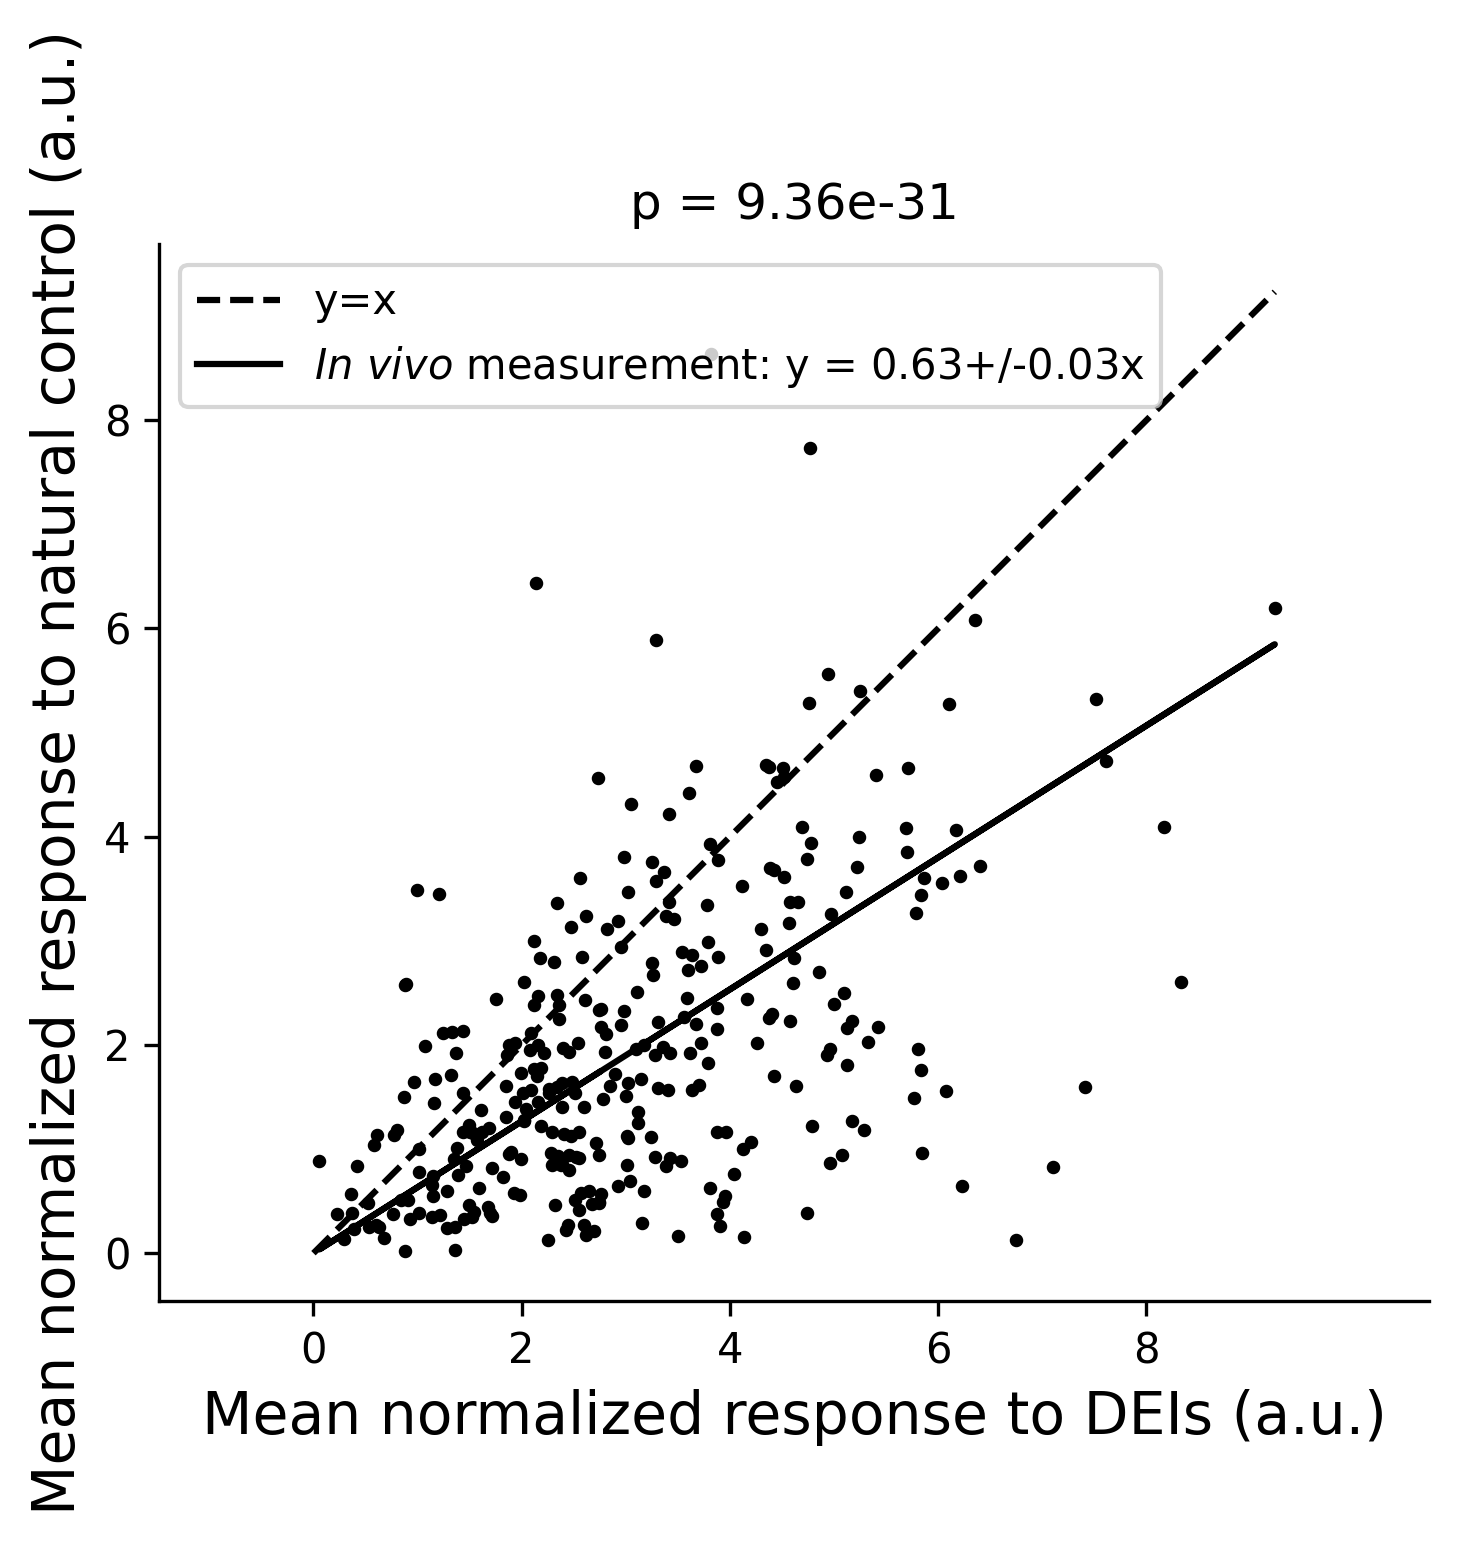

In [17]:
idx = 0
l = labels[idx]
x_mean = all_diags[idx]
x_std = all_std_diags[idx]

plt.figure(figsize=(5, 5), dpi=300)
ps = np.array([scipy.stats.ttest_ind_from_stats(m1,s1,n_repeats,m2,s2,n_repeats, equal_var=False)[1] for m1,s1,m2,s2 in zip(dei_mean, dei_std, x_mean, x_std)])
p_wc = scipy.stats.wilcoxon(dei_mean, x_mean)[1]
plt.scatter(dei_mean, x_mean, color='k', s=5, marker='o')

max_val = all_diags.max()
plt.plot([0, max_val], [0, max_val], color='k', linestyle='dashed', label='y=x')

from sklearn import linear_model
x = dei_mean[:, np.newaxis]
# robust fit
coefs = []
for i in range(1000):
    ransac = linear_model.RANSACRegressor(base_estimator=linear_model.LinearRegression(fit_intercept=False), max_trials=1000)
    ransac.fit(x, x_mean)
    coefs.append(ransac.estimator_.coef_.item())
coef = np.mean(coefs)
std_coef = np.std(coefs)
plt.plot(dei_mean, coef*dei_mean, color='k', label='$In\ vivo$ measurement: y = {:.2f}+/-{:.2f}x'.format(coef, std_coef))

plt.xlabel('Mean normalized response to DEIs (a.u.)', fontsize=14)
plt.ylabel('Mean normalized response to {} (a.u.)'.format(l), fontsize=14)

plt.title('p = {}'.format(np.format_float_scientific(p_wc, precision=2)))
plt.xticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.yticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])

plt.legend(loc=2)
sns.despine()
plt.tight_layout()
plt.axis('equal')
plt.savefig('/src/notebooks/Official_figures/[Fig3_c]Scatter_of_natural_control_and_DEI_responses.pdf', transparent=True)
get_stat(real[:, idx], real[:, -1])


## 3e-f

In [18]:
from staticnet_invariance.deis_reconfigured import *
from staticnet_pilots.analyses import scatterplot_helper
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine,pdist,squareform,cdist


In [21]:
class NeuralRepresentation():
    def __init__(self,model_key=None,threshold = True,pca_file_path='resp_pca.pickle',device='cuda:0'):
        if model_key is None:
            model_key = {'group_id': 285,'net_hash': '8b6fe18fa651ebf452db0fbd77d05a01',
                         'data_hash': '7572eed73113c993e7d1b92f83e270b4','readout_key': 'group285-28120-4-9-9','seed': 1009,'ssid':1}
        if threshold:
            oracle, corr = (EnsembleEval.Unit & model_key).fetch('oracle_score', 'unit_avg_corr')
            ora_thre = np.percentile(oracle, 100 - np.sqrt(0.75)*100)
            corr_thre = np.percentile(corr, 100 - np.sqrt(0.75)*100)
            neuron_ids = (EnsembleEval.Unit & model_key & 'oracle_score > {} and unit_avg_corr > {}'.format(ora_thre, corr_thre)).fetch('neuron_id',order_by='neuron_id')
            model_key['neuron_id'] = neuron_ids
        else:
            model_key['neuron_id'] = slice(None, None, None)
        
        self.model = NeuralRepresentation.get_model(model_key,neuron_ids=model_key['neuron_id'],device=device)
        self.device = device
        
        if pca_file_path is None:
            pca = self.get_pca()
        else:
            if  os.path.exists(pca_file_path):
                with open(pca_file_path, 'rb') as handle:
                    pca = pickle.load(handle)
            else:
                pca = self.get_pca()
                with open(pca_file_path, 'wb') as handle:
                    pickle.dump(pca, handle, protocol=pickle.HIGHEST_PROTOCOL)
        self.pca = pca
        
    def get_model(key,neuron_ids=None,device='cuda:0',center=True):
        # Get model
        model_key = ({'group_id': key['group_id'], 'net_hash': key['net_hash']})
        all_keys = (static_models.Model & model_key & 'seed > 1000').fetch('KEY')
        all_models = [(static_models.Model & mk).load_network() for mk in all_keys]
        all_models = [model.to(device) for model in all_models]
        if center:
            # Set all the centers
            for model in all_models:
                model.readout[key['readout_key']].grid.data = torch.zeros_like(model.readout[key['readout_key']].grid,dtype=torch.float32,device=device)

        mean_eyepos = ([0, 0] if (Dataset.TrainStats & key).fetch1('norm_eyepos') else
                       (Dataset.TrainStats & key).fetch1('mean_eyepos'))
        mean_eyepos = torch.tensor(mean_eyepos, dtype=torch.float32, device=device).unsqueeze(0)
        if neuron_ids is not None:
            model = models.Ensemble(all_models, key['readout_key'], eye_pos=mean_eyepos,
                                    neuron_idx=neuron_ids, device=device, average_batch=False)
        else:
            model = models.Ensemble(all_models, key['readout_key'], eye_pos=mean_eyepos,
                                    device=device, average_batch=False)
        return model
    def pass_img(imgs,model,device,batch_size=32):
        import math
        n_batch = int(math.ceil(len(imgs)/batch_size))
        y = []
        with torch.no_grad():
            for x in np.array_split(imgs,n_batch):
                x = torch.tensor(x,dtype=torch.float32,device=device).unsqueeze(1)
                y.append(model(x).cpu().numpy().squeeze())
        return np.concatenate(y)
    
    def get_resp_helper(imgs,model,device='cuda:0'):
        resp_shape = list(imgs.squeeze().shape[:-2])+[-1]
        imgs = imgs.reshape(-1,imgs.shape[-2],imgs.shape[-1])
        resp = NeuralRepresentation.pass_img(imgs,model,device=device,batch_size=32).reshape(resp_shape)
        return resp
    
    def standardize_helper(x):
        return (x-x.mean())*0.25/x.std()
    
    def standardize(imgs,mask_x,mask_y,standardize_std=True):
        if len(imgs.squeeze().shape)<3:
            imgs = imgs[None,:,:]
        if standardize_std:
            imgs = np.stack([NeuralRepresentation.standardize_helper(ops.create_whole_mei(ops.center_and_crop_image(img,mask_x,mask_y)[0],None,0,0,(36,64),False)) for img in imgs])
        else:
            imgs = np.stack([ops.create_whole_mei(ops.center_and_crop_image(img,mask_x,mask_y)[0],None,0,0,(36,64),False) for img in imgs])
        return imgs
    
    def transform(self,imgs,mask_x,mask_y,standardize_std=True):
        imgs = NeuralRepresentation.standardize(imgs,mask_x,mask_y)
        resps = NeuralRepresentation.get_resp_helper(imgs,self.model,device=self.device)
        if len(resps.shape)<2:
            resps = resps[None,:]
        X = self.pca.transform(resps)
        return X
    
    def get_pca(self):
        # compile MEIs from all datasets
        all_meis, all_xs, all_ys = [], [], []
        groups = [233, 237, 239, 243, 271, 272, 275, 279, 284, 285, 329, 330, 336, 337]
        net_hash = ["8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da"]
        data_hash = ["7572eed73113c993e7d1b92f83e270b4"]
        group_keys = (base.EnsembleEval & 'ssid = 1' & [{'group_id': i} for i in groups] & [{'net_hash': i} for i in net_hash] & [{'data_hash': i} for i in data_hash]).fetch(dj.key, order_by='group_id')

        for key in group_keys:
            rest = {'mei_params': 10, 'mask_params': 3, 'seed': 1009}
            rel = base.UnitRanking.Unit & dict(ranking_params=4) & key
            oracle, corr = (EnsembleEval.Unit & key & rel).fetch('oracle_score', 'unit_avg_corr')
            ora_thre = np.percentile(oracle, 100 - np.sqrt(0.75)*100)
            corr_thre = np.percentile(corr, 100 - np.sqrt(0.75)*100)
            meis, xs, ys = (base.MEI * base.MEIMask * EnsembleEval.Unit & key & rel & 'oracle_score > {} and unit_avg_corr > {}'.format(ora_thre, corr_thre) & rest).fetch('mei', 'mask_x', 'mask_y', order_by='neuron_id')
            np.random.seed(1234)
            selected_idxs = np.random.choice(np.arange(len(meis)), 500, replace=False)
            all_meis.extend(meis[selected_idxs])
            all_xs.extend(xs[selected_idxs])
            all_ys.extend(ys[selected_idxs])
            
        meis = np.stack([NeuralRepresentation.standardize(mei,mask_x,mask_y,standardize_std=True) for mei,mask_x,mask_y in zip(all_meis,all_xs,all_ys)])
        resps = NeuralRepresentation.get_resp_helper(imgs = meis,model=self.model)
        from sklearn.decomposition import PCA
        pca = PCA()
        X = resps
        pca.fit(X)
        x = np.arange(1,len(pca.explained_variance_ratio_)+1)
        y = np.cumsum(pca.explained_variance_ratio_)
        x_thres = x[np.argmin(abs(y-0.95))]
        pca = PCA(n_components=x_thres)
        pca.fit(X)
        return pca
    
def permutation_test(X,n_repeats = 10000, seed=None):
    if seed is not None:
        np.random.seed(seed)
    diag_mean = np.diag(X).mean()
    bootstrap_means = []
    for _ in tqdm(range(n_repeats)):
        bootstrap_means.append(np.random.choice(X.ravel(),len(np.diag(X)),replace=False).mean())
    bootstrap_means = np.array(bootstrap_means)                 
    return (bootstrap_means>diag_mean).sum()/len(bootstrap_means)

def avg_pair_dist(x,y,n_dim=53):
    x = x.reshape(-1,n_dim)
    y = y.reshape(-1,n_dim)
    return (1.0-cdist(x,y,metric='cosine')).mean()

In [22]:
# model ensemble with seeds 1009, 1215, 2606, 99999, starting from MEI or white noise
mei_1009 = {'seed':1009, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 17, 'threshold_params': 2, 'texture_params': 20,  'score_params': 2}
wn_1009 = {'seed':1009, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20,  'score_params': 2}

# model ensemble with seeds 101, 102, 103, 104, starting from MEI or white noise
mei_101 = {'seed':101, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 17, 'threshold_params': 2, 'texture_params': 20,  'score_params': 2}
wn_101 = {'seed':101, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20,  'score_params': 2}

# individual model with seed 1009 or 2606
indi_1009 = {'seed': 1009, 'mei_params':12, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 17, 'threshold_params': 2, 'texture_params': 26,  'score_params': 2}
indi_2606 = {'seed': 2606, 'mei_params':12, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 17, 'threshold_params': 2, 'texture_params': 26,  'score_params': 2}

represent_1009 = {'seed': 1009, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 21, 'threshold_params': 2}

image_types = ['Original ensemble from MEI', 'Original ensemble from white noise',
                'New ensemble from MEI', 'New ensemble from white noise',
                'Individual model 1 from MEI', 'Individual model 2 from MEI',
               'Representational DEI',
               'Sensorium seed 1', 'Sensorium seed 2' ,'Luca 1d DEI','Luca 2d DEI',]

keys = (NeuronSetRequest & 'method_id = 20' & mei_1009).fetch('KEY',order_by='group_id,neuron_id')
for key in keys:
    del key['seed']
    del key['method_id']
completed_indices = {i:None for i in image_types[:6]}
for i,j in zip([mei_1009, wn_1009, mei_101, wn_101, indi_1009, indi_2606],image_types[:6]):
    completed_indices[j] = np.array([True if len(((DEI * DEIGoodRun) & i & key))==1 else False for key in keys])
completed_indices = np.stack(list(completed_indices.values())).all(axis=0)
keys = [keys[i] for i in np.where(completed_indices)[0]]

In [24]:
# neural_representation = NeuralRepresentation()
dei_divs = {i:None for i in image_types}
pc_coefs = {i:[] for i in image_types}


full_1 = {'seed':1009, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 14, 'threshold_params': 2, 'texture_params': 13,  'score_params': 2}
full_2 = {'seed':1009, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 17, 'threshold_params': 2, 'texture_params': 20,  'score_params': 2}

for i,j in zip([mei_1009, wn_1009, mei_101, wn_101, indi_1009, indi_2606,represent_1009,None,None,None,None],image_types):
    if j in ['Full texture','Partial texture']:
        if j == 'Partial texture':
            temp = [(MEIMask * Texture * TextureGoodRun & full_1 & keys & 'group_id <= 237'),
                    (MEIMask * Texture * TextureGoodRun & full_2 & keys & 'group_id > 237')]
        else:
            temp = [(MEIMask * Texture & {'texture_id':-1} & full_1 & keys & 'group_id <= 237'),
                    (MEIMask * Texture & {'texture_id':-1} & full_2 & keys & 'group_id > 237')]
            
        temp = [i.fetch('KEY','mask_x','mask_y','samples','sample_avg_div',order_by='group_id,neuron_id') for i in temp]
        deis = np.concatenate([np.array(i[-2]) for i in temp])
        dei_div = np.concatenate([np.array(i[-1]) for i in temp]) * -1.0
        mask_xs = np.concatenate([np.array(i[1]) for i in temp])
        mask_ys = np.concatenate([np.array(i[2]) for i in temp])
        dei_key = temp[0]+temp[1]
        
    elif j == 'Random DEI':
        dei_key,mask_xs, mask_ys, deis, dei_div = \
        (MEIMask * DEI * DEIGoodRun & i & ((NeuronSetRequest & 'method_id = 3') \
                                           - (NeuronSetRequest & 'method_id = 20'))).fetch('KEY','mask_x','mask_y','deis','avg_sim',order_by='group_id,neuron_id')
        idxs = np.random.choice(len(deis),len(keys),replace=False)
        deis = deis[idxs]
        mask_xs = mask_xs[idxs]
        mask_ys = mask_ys[idxs]
        
    elif j in ['Sensorium seed 1','Sensorium seed 2']:
        if j == 'Sensorium seed 1':
            add_rest = {'seed':101}
        else:
            add_rest = {'seed':1009}
        rest = {'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 17, 'threshold_params': 2}
        neuron_rel = NeuronSetRequest & 'method_id = 23'
        temp = [{'group_id':i['group_id'],'neuron_id':i['neuron_id']} for i in keys]
        dei_key, mask_xs, mask_ys, deis, dei_div = (MEIMask * DEI * DEIGoodRun & rest & add_rest & neuron_rel & temp).fetch('KEY','mask_x','mask_y','deis','avg_sim',order_by='group_id,neuron_id')
    
    elif j in ['Luca 1d DEI','Luca 2d DEI']:
        def check_if_subset(x,y):
            return x.items() <= y.items()

        if j == 'Luca 1d DEI':
            with open('/src/notebooks/data/new_1d_results_0.85avg.pickle','rb') as handle:
                temp = pickle.load(handle)
                img_name = 'uniformely_sampled_latent_space_imgs'
        elif j == 'Luca 2d DEI':
            with open('/src/notebooks/data/2d_results_0.85avg.pickle','rb') as handle:
                temp = pickle.load(handle)
                img_name = 'optimized_imgs_avg'
                
        deis,dei_key = [],[]
        
        for individual_key in keys:
            for individual_result in temp:
                if check_if_subset({'group_id':individual_key['group_id'],'neuron_id':individual_key['neuron_id']},individual_result):
                    deis.append(individual_result[img_name].cpu().detach().squeeze().numpy())
                    dei_key.append(individual_key)
        dei_div = []
        meis, masks, mask_xs, mask_ys = (MEI * MEIMask * (DEI * DEIGoodRun) & mei_1009 & keys).fetch('mei', 'mask', 'mask_x', 'mask_y', order_by='group_id, neuron_id')
        for mei, mask, dei in zip(meis, masks, deis):
            f = ops.Similarity(weight=1,metric="neg_euclidean",combine_op=ops.DoNothing(),mask=mask)
            dei_div.append(f(torch.tensor(np.concatenate([mei[None], dei], axis=0),dtype=torch.float32)).mean().item())
                    
    else:
        temp = (MEI * MEIMask * (DEI * DEIGoodRun) & i & keys)
        dei_key, meis, masks, mask_xs, mask_ys, deis,dei_div = temp.fetch('KEY','mei', 'mask','mask_x','mask_y','deis','avg_sim',order_by='group_id,neuron_id')
        if j == 'Representational DEI':
            dei_div = []
            for mei, dei, mask in zip(meis, deis, masks):
                f = ops.Similarity(weight=1,metric="neg_euclidean",combine_op=ops.DoNothing(),mask=mask)
                dei_div.append(f(torch.tensor(np.concatenate([mei[None], dei], axis=0),dtype=torch.float32).contiguous()).mean().item())

    dei_divs[j] = np.array(dei_div)*-1.0
    pc_coefs[j] = np.stack([neural_representation.transform(dei,mask_x,mask_y,standardize_std=True).squeeze() for dei,mask_x,mask_y in zip(deis,mask_xs,mask_ys)])

In [25]:
for i in image_types:
    print(i,pc_coefs[i].shape)

Original ensemble from MEI (97, 20, 53)
Original ensemble from white noise (97, 20, 53)
New ensemble from MEI (97, 20, 53)
New ensemble from white noise (97, 20, 53)
Individual model 1 from MEI (97, 20, 53)
Individual model 2 from MEI (97, 20, 53)
Representational DEI (97, 20, 53)
Sensorium seed 1 (97, 20, 53)
Sensorium seed 2 (97, 20, 53)
Luca 1d DEI (97, 20, 53)
Luca 2d DEI (97, 20, 53)


### Similarity comparison

In [27]:
N_DIM=53

ps = {i:None for i in image_types}
dist_matrices = {i:None for i in image_types}
for image_type in tqdm(image_types):
    X = pc_coefs[image_type]
    dist_matrix = np.zeros([len(X),len(X)])
    for i in tqdm(range(len(X))):
        for j in range(len(X)):
            if i<=j:
                dist_matrix[i,j] = avg_pair_dist(X[i],X[j],n_dim=N_DIM)
            else:
                dist_matrix[i,j] = dist_matrix[j,i]
    dist_matrices[image_type] = dist_matrix

cross_dists = np.ones([len(image_types),len(image_types),completed_indices.sum()])
p1s,p2s = np.ones([len(image_types),len(image_types)]), np.ones([len(image_types),len(image_types)])
np.random.seed(0)

for i,image_type1 in enumerate(image_types):    
    for j,image_type2 in enumerate(image_types):
        cross_dists[i,j] = np.array([avg_pair_dist(x,y,n_dim=N_DIM) for x,y in zip(pc_coefs[image_type1],pc_coefs[image_type2])])

100%|██████████| 11/11 [00:01<00:00,  6.58it/s]


### Get distance to random neurons from random samples in the off diagonal of the original DEI matrix

In [28]:
mat = dist_matrices['Original ensemble from MEI']
idxs = np.where(~np.eye(mat.shape[0],dtype=bool))
np.random.seed(1234)
cols = np.array([np.random.choice(i, 1).item() for i in idxs[1].reshape(len(mat), len(mat)-1)])
rows = np.arange(len(mat))
sampled_idxs = (rows, cols)
random_dists = mat[sampled_idxs]

### Get statistics (postive control)

In [29]:
from scipy.stats import wilcoxon
for i in range(1,len(image_types)):
    print(image_types[i])
    print(wilcoxon(cross_dists[0,0],cross_dists[0,i]))
print('Random DEIs')
print(wilcoxon(cross_dists[0,0],random_dists))

Original ensemble from white noise
WilcoxonResult(statistic=1368.0, pvalue=0.0002847207167827147)
New ensemble from MEI
WilcoxonResult(statistic=256.0, pvalue=2.3465298908131418e-14)
New ensemble from white noise
WilcoxonResult(statistic=302.0, pvalue=8.359330371188823e-14)
Individual model 1 from MEI
WilcoxonResult(statistic=13.0, pvalue=1.8249593800702007e-17)
Individual model 2 from MEI
WilcoxonResult(statistic=44.0, pvalue=4.743719113086157e-17)
Representational DEI
WilcoxonResult(statistic=128.0, pvalue=5.935725839361554e-16)
Sensorium seed 1
WilcoxonResult(statistic=27.0, pvalue=2.8136650753976834e-17)
Sensorium seed 2
WilcoxonResult(statistic=75.0, pvalue=1.2180130637623243e-16)
Luca 1d DEI
WilcoxonResult(statistic=1354.0, pvalue=0.00023397193979311608)
Luca 2d DEI
WilcoxonResult(statistic=1161.0, pvalue=1.2218426059283523e-05)
Random DEIs
WilcoxonResult(statistic=0.0, pvalue=1.218119098708288e-17)


### Get statistics (negative control)

In [30]:
from scipy.stats import wilcoxon
ps = []
for i in range(len(image_types)):
    print(image_types[i])
    print(wilcoxon(random_dists,cross_dists[0,i]))
    ps.append(wilcoxon(random_dists,cross_dists[0,i])[-1])

Original ensemble from MEI
WilcoxonResult(statistic=0.0, pvalue=1.218119098708288e-17)
Original ensemble from white noise
WilcoxonResult(statistic=0.0, pvalue=1.218119098708288e-17)
New ensemble from MEI
WilcoxonResult(statistic=1.0, pvalue=1.2566893713641387e-17)
New ensemble from white noise
WilcoxonResult(statistic=1.0, pvalue=1.2566893713641387e-17)
Individual model 1 from MEI
WilcoxonResult(statistic=34.0, pvalue=3.490390756430568e-17)
Individual model 2 from MEI
WilcoxonResult(statistic=0.0, pvalue=1.218119098708288e-17)
Representational DEI
WilcoxonResult(statistic=0.0, pvalue=1.218119098708288e-17)
Sensorium seed 1
WilcoxonResult(statistic=426.0, pvalue=2.2449470646593125e-12)
Sensorium seed 2
WilcoxonResult(statistic=357.0, pvalue=3.68556464352186e-13)
Luca 1d DEI
WilcoxonResult(statistic=0.0, pvalue=1.218119098708288e-17)
Luca 2d DEI
WilcoxonResult(statistic=0.0, pvalue=1.218119098708288e-17)


In [31]:
from statsmodels.stats.multitest import multipletests
multipletests(ps,0.05,method="fdr_bh")

(array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True]),
 array([1.72794789e-17, 1.72794789e-17, 1.72794789e-17, 1.72794789e-17,
        4.26603315e-17, 1.72794789e-17, 1.72794789e-17, 2.24494706e-12,
        4.05412111e-13, 1.72794789e-17, 1.72794789e-17]),
 0.004652171732197341,
 0.004545454545454546)

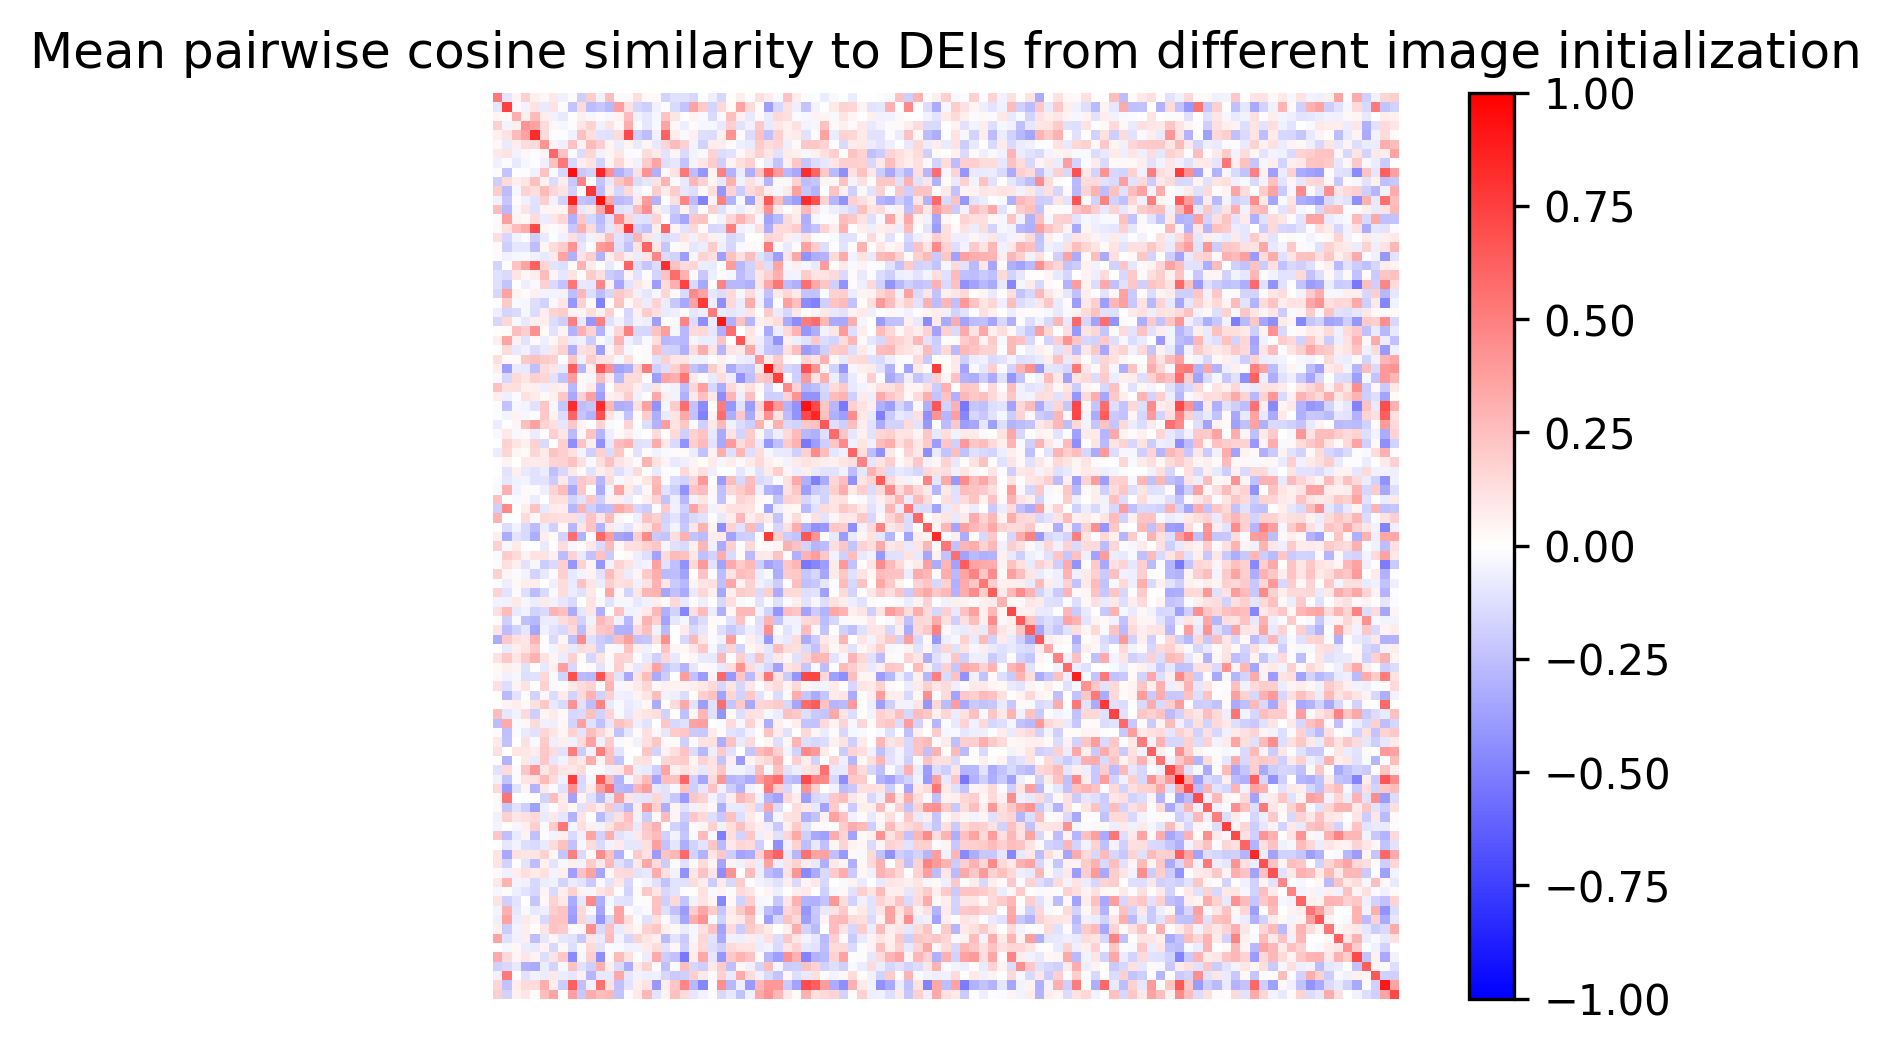

In [32]:
dist_matrix = np.array(dist_matrices[image_types[1]])
plt.figure(dpi=300)
plt.imshow(dist_matrix, cmap='bwr',vmin=-1,vmax=1)
plt.axis('off')
plt.colorbar()
plt.title('Mean pairwise cosine similarity to DEIs from different image initialization')
plt.savefig('/src/notebooks/Official_figures/[Fig3_e]Similarity_confusion_matrix_to_DEIs_from_different_image_initialization.pdf', transparent=True)

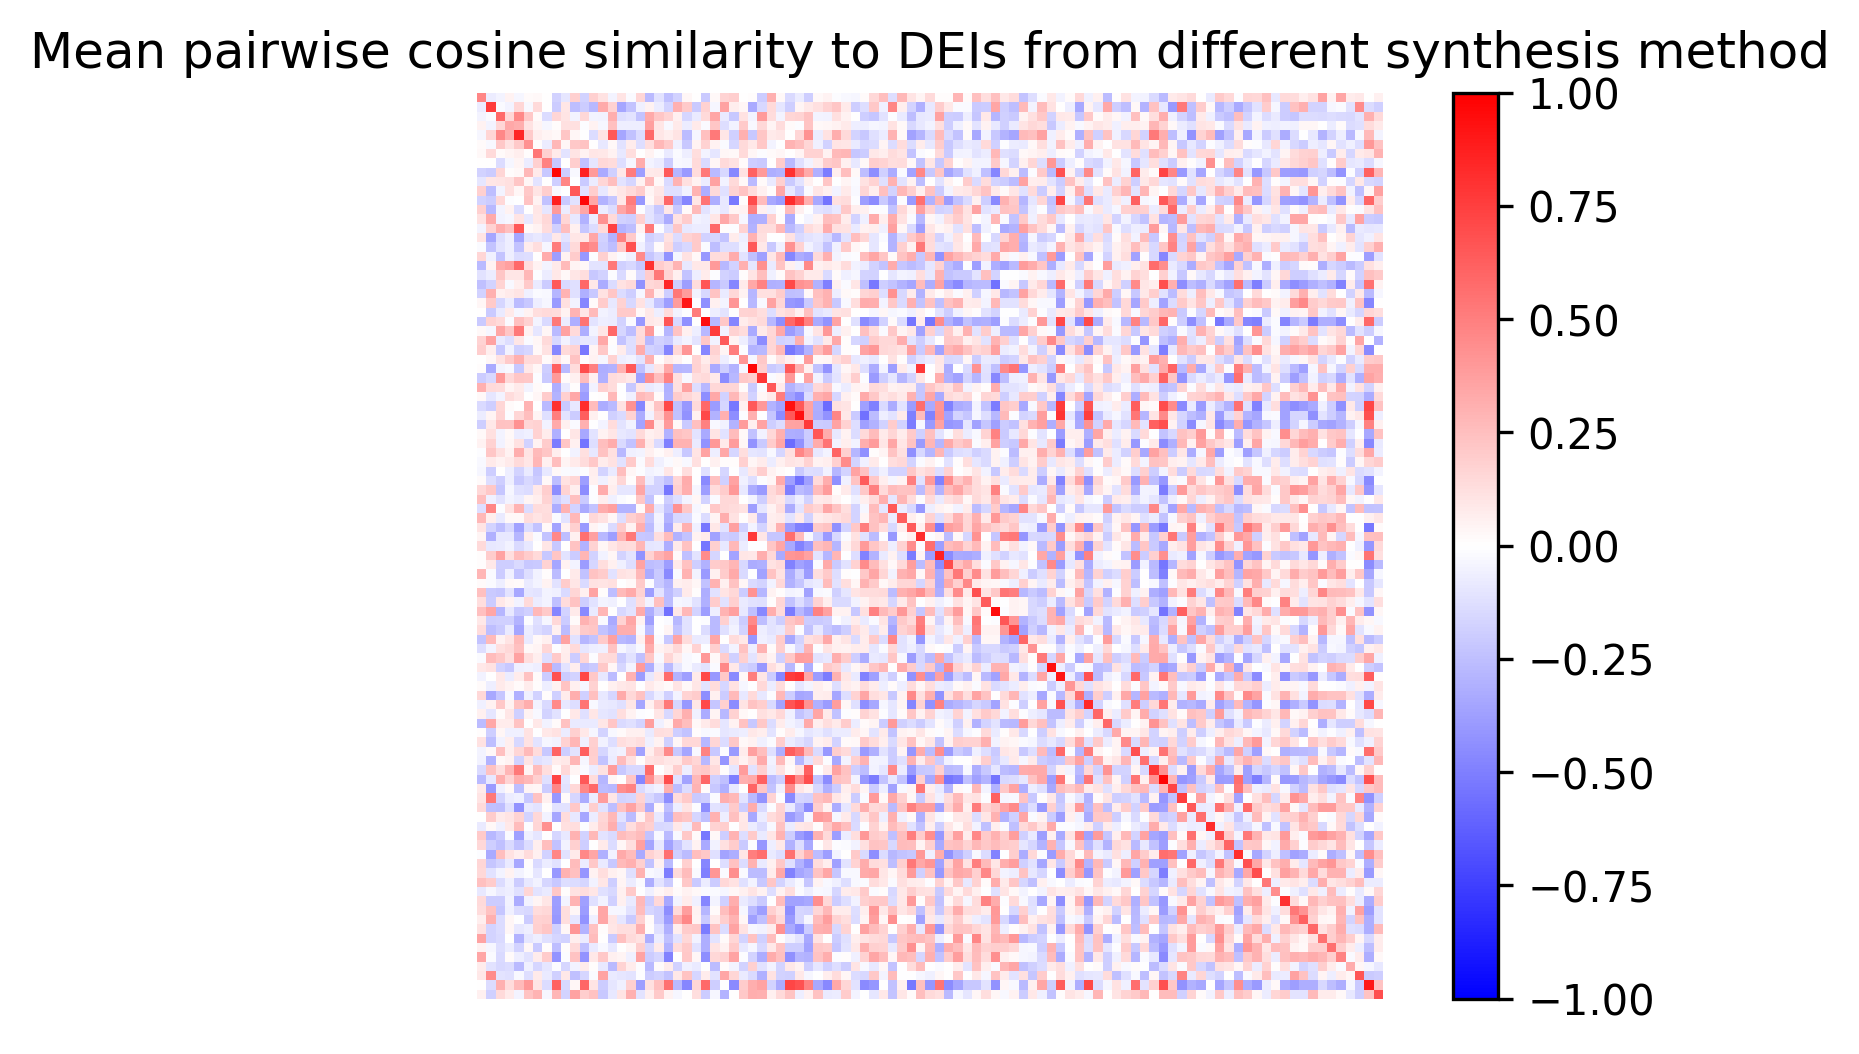

In [33]:
dist_matrix = np.array(dist_matrices[image_types[9]])
plt.figure(dpi=300)
plt.imshow(dist_matrix, cmap='bwr',vmin=-1,vmax=1)
plt.axis('off')
plt.colorbar()
plt.title('Mean pairwise cosine similarity to DEIs from different synthesis method')
plt.savefig('/src/notebooks/Official_figures/[Fig3_e]Similarity_confusion_matrix_to_different_synthesis_method.pdf', transparent=True)

### Boxplot for a selected set of methods

In [25]:
idxs = np.array([0,1,2,6,9,7]).astype(int)
print([image_types[i] for i in idxs])

['Original ensemble from MEI', 'Original ensemble from white noise', 'New ensemble from MEI', 'Representational DEI', 'Luca 1d DEI', 'Sensorium seed 1']


Boxplot statistics per group:

Original (idx=0):
              min: 0.2876
              max: 0.9640
           median: 0.5944
               q1: 0.4763
               q3: 0.7052
              iqr: 0.2289
    lower_whisker: 0.2876
    upper_whisker: 0.9640
              p10: 0.4018
              p90: 0.8348
             mean: 0.6056
              std: 0.1655

From white noise (idx=1):
              min: 0.2849
              max: 0.9567
           median: 0.5906
               q1: 0.4730
               q3: 0.7111
              iqr: 0.2382
    lower_whisker: 0.2849
    upper_whisker: 0.9567
              p10: 0.4028
              p90: 0.8350
             mean: 0.5998
              std: 0.1665

New ensemble (idx=2):
              min: 0.0698
              max: 0.9112
           median: 0.4978
               q1: 0.3972
               q3: 0.6492
              iqr: 0.2519
    lower_whisker: 0.0698
    upper_whisker: 0.9112
              p10: 0.2847
              p90: 0.8008
             mean

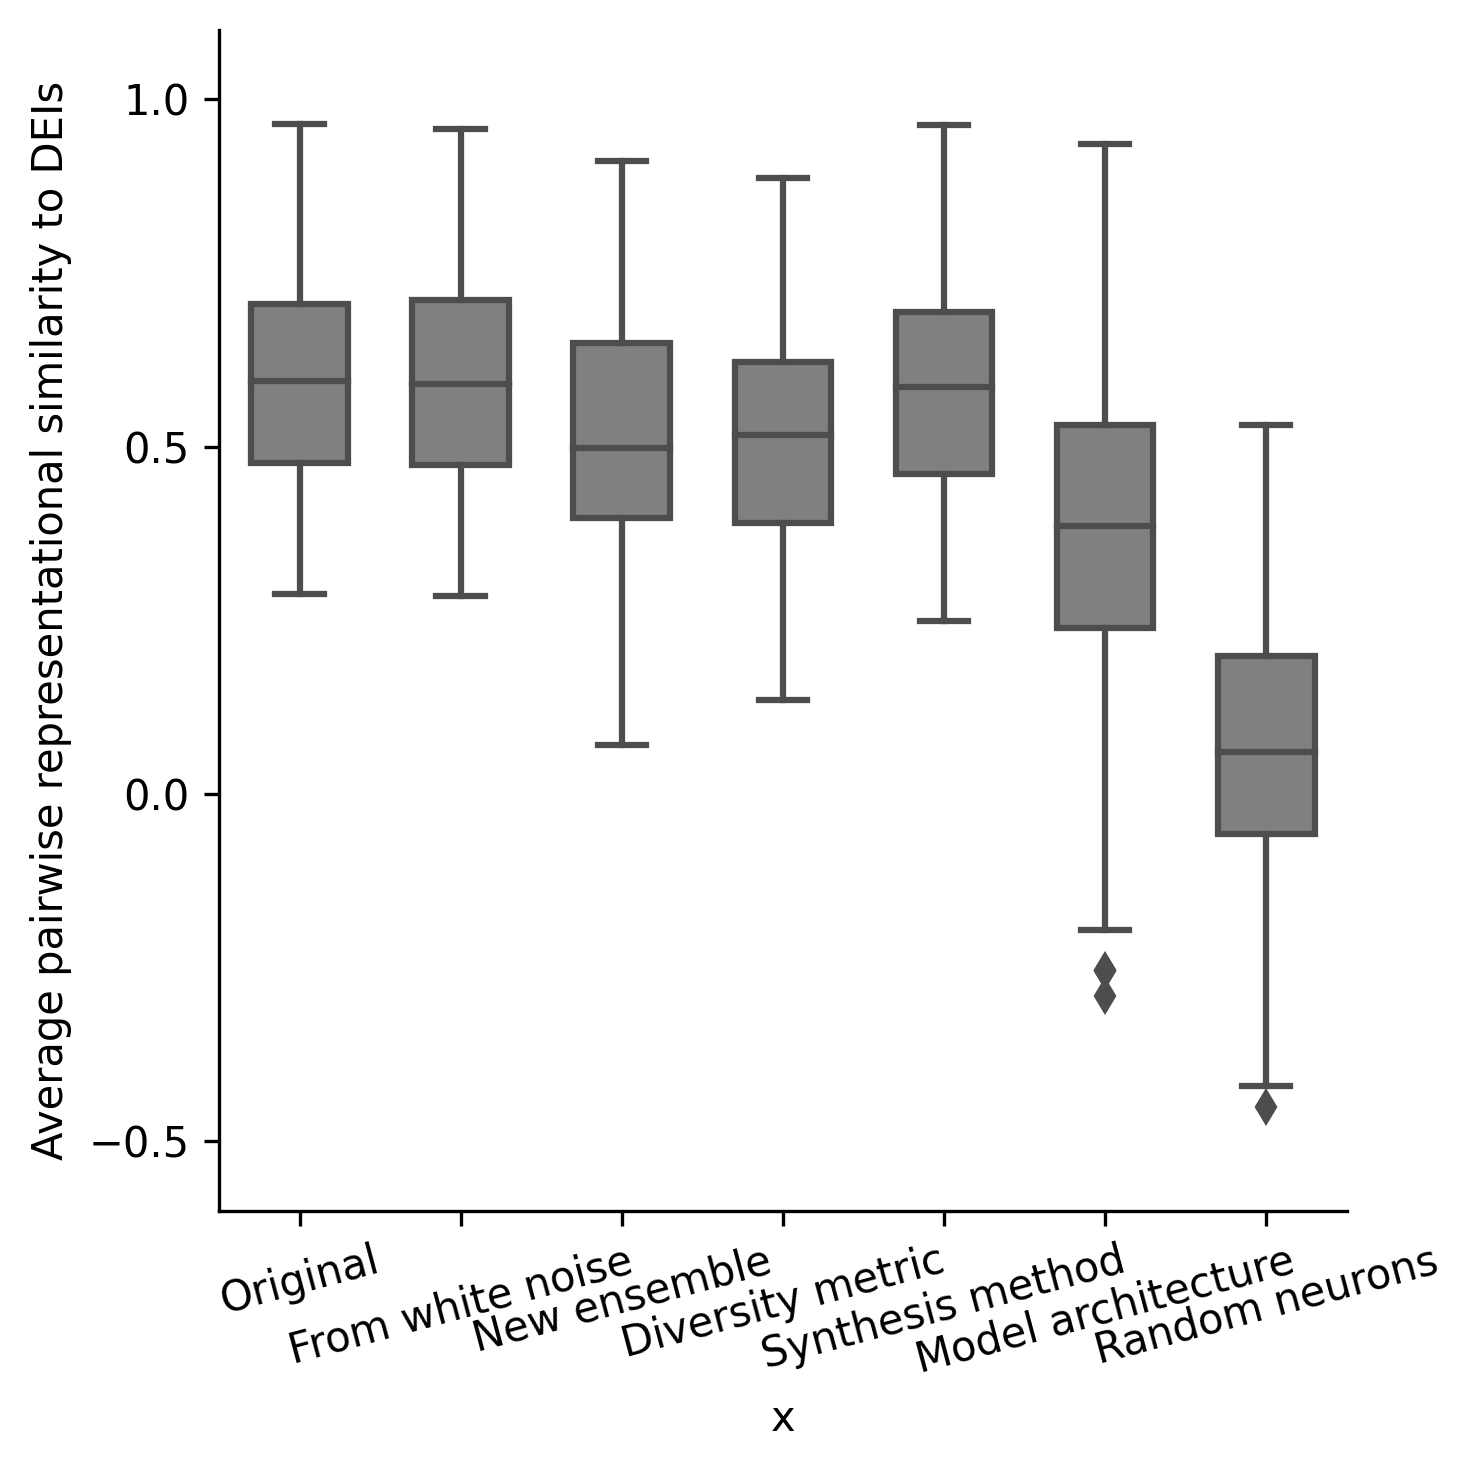

<Figure size 432x288 with 0 Axes>

In [37]:
plt.figure(figsize=(5, 5), dpi=300)
idxs = np.array([0,1,2,6,9, 7]+[100]).astype(int)
y_labels = ['Original', 'From white noise', 'New ensemble', 'Diversity metric', 'Synthesis method', 'Model architecture', 'Random neurons']

x = np.concatenate(np.array([[i]*len(pc_coefs[image_types[0]]) for i in idxs]))
y = np.concatenate([cross_dists[0][idxs[:-1]], random_dists[None]], axis=0).ravel()

# Convert to DataFrame for easier manipulation
df = pd.DataFrame({'x': x, 'y': y})

# Compute boxplot stats
stats = {}
for label in idxs:
    data = df[df['x'] == label]['y']
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    median = np.percentile(data, 50)
    iqr = q3 - q1
    lower_whisker = np.min(data[data >= q1 - 1.5 * iqr])
    upper_whisker = np.max(data[data <= q3 + 1.5 * iqr])
    stats[label] = {
        'min': data.min(),
        'max': data.max(),
        'median': median,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_whisker': lower_whisker,
        'upper_whisker': upper_whisker,
        'p10': np.percentile(data, 10),
        'p90': np.percentile(data, 90),
        'mean': np.mean(data),
        'std': np.std(data)
    }

# Print nicely formatted results
print("Boxplot statistics per group:")
for label, vals in stats.items():
    print(f"\n{y_labels[list(idxs).index(label)]} (idx={label}):")
    for k, v in vals.items():
        print(f"  {k:>15}: {v:.4f}")

# Plot
sns.boxplot(x='x', y='y', data=df, order=idxs, width=0.6, color='gray')
plt.ylabel('Average pairwise representational similarity to DEIs')
plt.yticks([-0.5, 0, 0.5, 1])
plt.ylim(-0.6, 1.1)
plt.xticks(ticks=range(len(y_labels)), labels=y_labels, rotation=15)
sns.despine()
plt.tight_layout()
plt.show()
plt.savefig('/src/notebooks/Official_figures/[Fig3_f]Representational_similarity_to_pixel_DEIs.pdf', transparent=True)

### Get statistics of all boxes

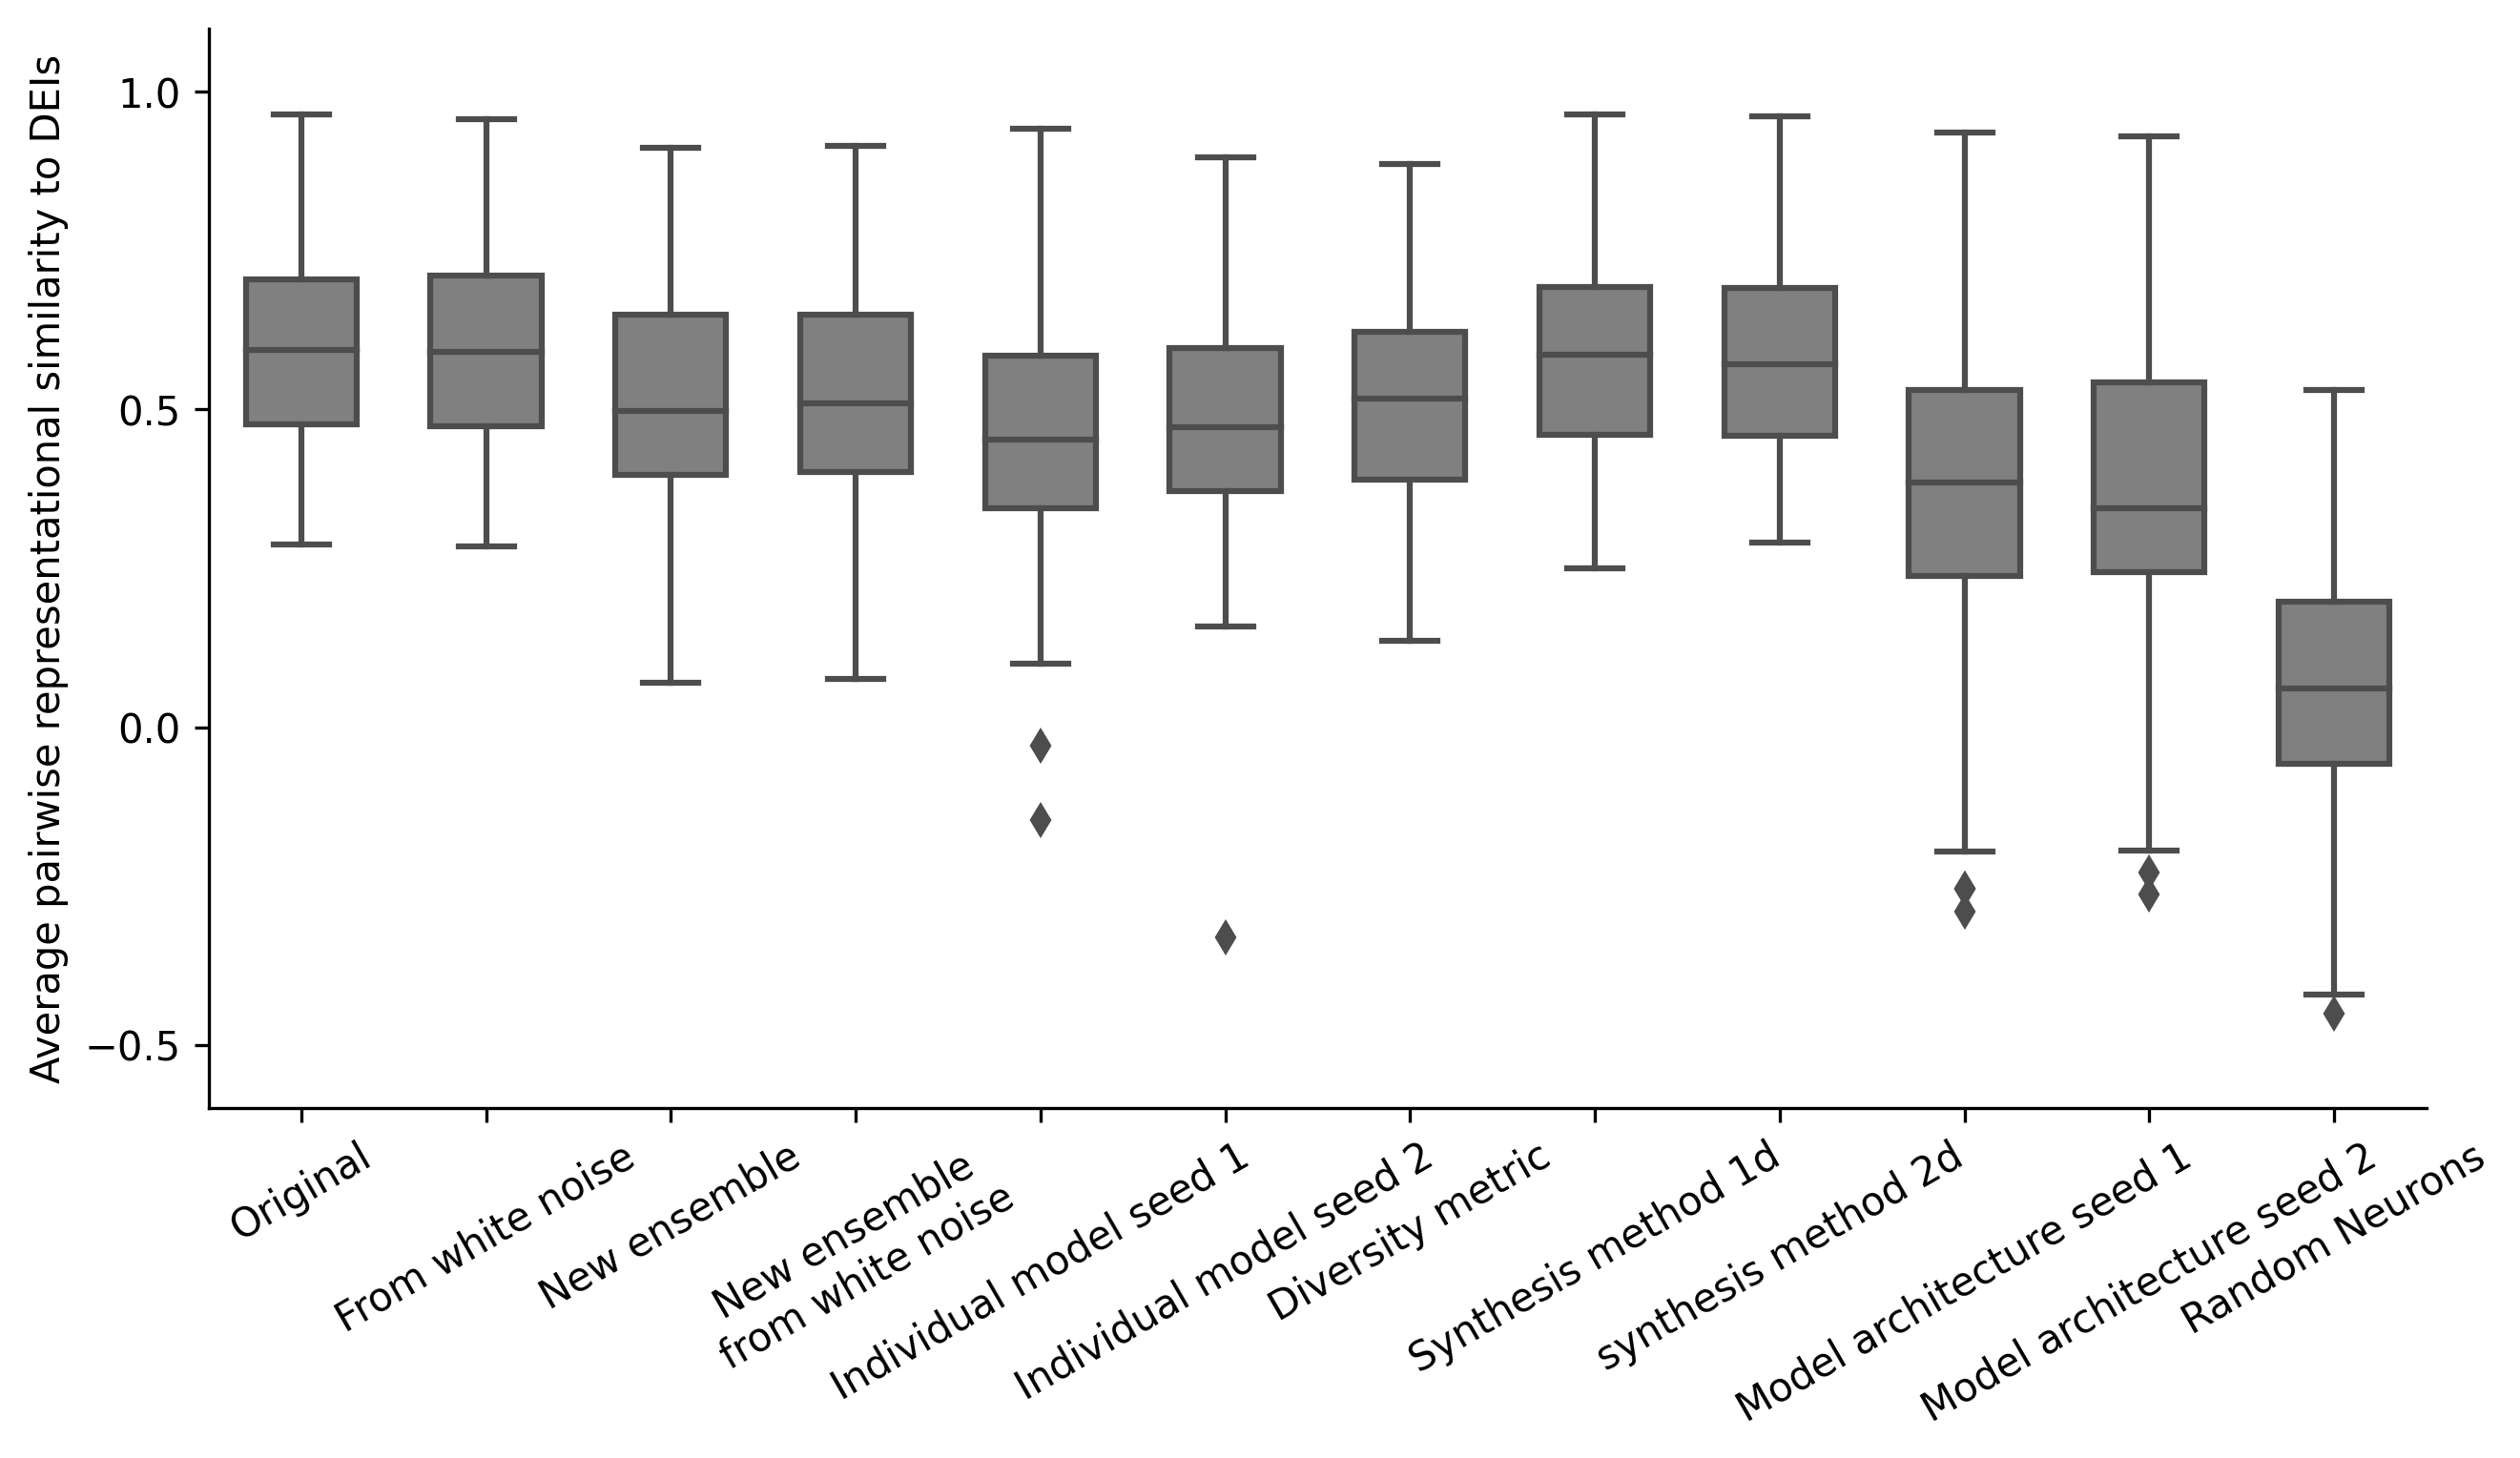

In [38]:
plt.figure(figsize=(10, 5), dpi=300)
# to get all the generalization boxes
idxs = np.array(list(range(7)) + [9, 10, 7, 8] + [100])
y_labels = ['Original', 'From white noise', 'New ensemble', 'New ensemble\nfrom white noise', 'Individual model seed 1', 'Individual model seed 2', 'Diversity metric', 'Synthesis method 1d', 'synthesis method 2d', 'Model architecture seed 1', 'Model architecture seed 2', 'Random Neurons']

x = np.concatenate(np.array([[i]*len(pc_coefs[image_types[0]]) for i in idxs]))
y = np.concatenate([cross_dists[0][idxs[:-1]], random_dists[None]], axis=0).ravel()

sns.boxplot(x=x, y=y, order=idxs, width=0.6, color='gray')
plt.ylabel('Average pairwise representational similarity to DEIs')
plt.yticks([-0.5,0,0.5,1])
#plt.xlim(-1.1,1.1)
plt.ylim(-0.6,1.1)
plt.xticks(plt.gca().get_xticks(), y_labels)
sns.despine()
plt.xticks(rotation=30)
plt.show()
